In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate Data

In [2]:
X_train = np.linspace(-1, 1, 20)

In [3]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [4]:
X_test = np.linspace(-1, 1, 20)

In [5]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

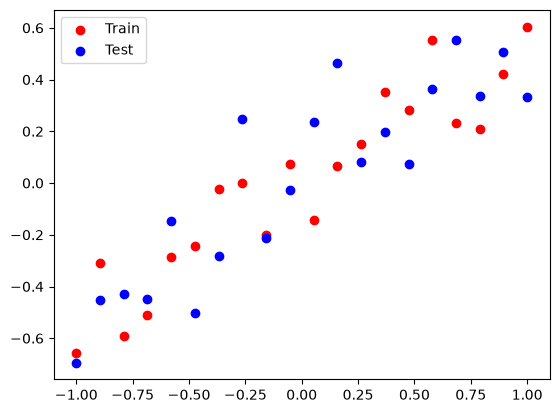

In [6]:
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

# Regression Model

In [8]:
model_1 = Sequential()
model_1.add(Dense(128, input_dim=1, activation="relu"))
model_1.add(Dense(128, activation="relu"))
model_1.add(Dense(1, activation="linear"))
adam = Adam(learning_rate=0.01)
model_1.compile(loss='mse', optimizer=adam, metrics=['mse'])
history = model_1.fit(X_train, y_train, epochs=500, 
                    validation_data = (X_test, y_test),
                    verbose=1)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.1844 - mse: 0.1844 - val_loss: 0.0372 - val_mse: 0.0372
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - loss: 0.0264 - mse: 0.0264 - val_loss: 0.0504 - val_mse: 0.0504
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - loss: 0.0392 - mse: 0.0392 - val_loss: 0.0513 - val_mse: 0.0513
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - loss: 0.0386 - mse: 0.0386 - val_loss: 0.0369 - val_mse: 0.0369
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - loss: 0.0233 - mse: 0.0233 - val_loss: 0.0337 - val_mse: 0.0337
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - loss: 0.0202 - mse: 0.0202 - val_loss: 0.0372 - val_mse: 0.0372
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step - loss: 0.0238 - mse: 0.0238 - val_loss: 0.0402 - val_mse: 0.0402
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - loss: 0.0269 - mse: 0.0269 - val_loss: 0.0388 - val_mse: 0.0388
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - loss: 0.0254 -

In [9]:
# evaluate the model
_, train_mse = model_1.evaluate(X_train, y_train, verbose=0)
_, test_mse = model_1.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.003981010057032108, Test: 0.043947067111730576


In [10]:
y_pred_1 = model_1.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


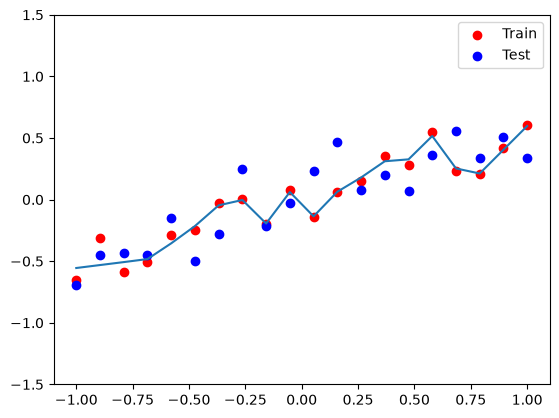

In [11]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

# Dropout Model

In [13]:
model_2 = Sequential()
model_2.add(Dense(128, input_dim=1, activation="relu"))
model_2.add(Dropout(0.2))
model_2.add(Dense(128, activation="relu"))
model_2.add(Dropout(0.2))
model_2.add(Dense(1, activation="linear"))
adam = Adam(learning_rate=0.01)
model_2.compile(loss='mse', optimizer=adam, metrics=['mse'])

drop_out_history = model_2.fit(X_train, y_train, epochs=500, 
                               validation_data = (X_test, y_test),
                               verbose=1)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.1597 - mse: 0.1597 - val_loss: 0.0378 - val_mse: 0.0378
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - loss: 0.0261 - mse: 0.0261 - val_loss: 0.0617 - val_mse: 0.0617
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.0479 - mse: 0.0479 - val_loss: 0.0479 - val_mse: 0.0479
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.0476 - mse: 0.0476 - val_loss: 0.0350 - val_mse: 0.0350
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.0245 - mse: 0.0245 - val_loss: 0.0403 - val_mse: 0.0403
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 0.0258 - mse: 0.0258 - val_loss: 0.0438 - val_mse: 0.0438
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - loss: 0.0305 - mse: 0.0305 - val_loss: 0.0428 - val_mse: 0.0428
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - loss: 0.0344 - mse: 0.0344 - val_loss: 0.0392 - val_mse: 0.0392
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - loss: 0.0256 -

In [15]:
# evaluate the model
_, train_mse = model_2.evaluate(X_train, y_train, verbose=0)
_, test_mse = model_2.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.010329373180866241, Test: 0.04079701378941536


In [16]:
y_pred_2 = model_2.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


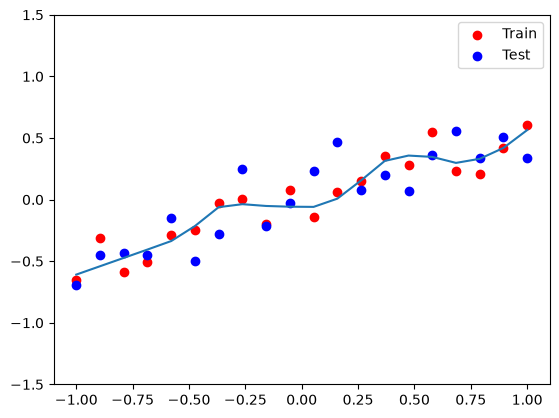

In [17]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()